<a href="https://colab.research.google.com/github/Wunzir/Projects-in-AI-ML/blob/main/hw06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Part 1: Reinforcement Learning**
### **Task 1:**
Implement value iteration or policy iteration for a small discrete Markov Decision Process (MDP)

You may use a grid world, FrozenLake, inventory control, or another small discrete environment approved in class.

**Perform the following:**
- Clearly define the state space, action space, reward structure, and discount factor.
- Implement either value iteration or policy iteration and compute the final policy.
- Show the learned value function and the final policy in a readable form.
- Run at least one small experiment showing how the policy changes when you vary either the discount factor or the reward design.
- Briefly discuss why this setup is an MDP and what the learned policy is doing.

In [1]:
"""
IMPORT STATEMENTS
"""
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
"""
THE GRID-WORLD ENVIRONMENT
"""
class GridWorld:
  """
  Defines the physics and rules of our MDP
  """
  def __init__(self):
    """
    Constructor, initializing the enviornment
    """
    self.grid_size = 4 # 4x4 grid
    self.actions = [(-1,0), (1,0), (0,-1), (0,1)] # Up, Down, Left, Right
    # Coordinates for special states
    self.goal = (0,3)
    self.trap = (1,3)
    self.wall = (1,1)

  def get_states(self):
    """
    Returns a list of all valid coordinates on the board (skipping the wall)
    """
    states = []
    for r in range(self.grid_size):
      for c in range(self.grid_size):
        if (r,c) != self.wall:
          states.append((r,c))

    return states

  def step(self, state, action):
    """
    Core physics engine. Takes in a current coordinate and action and calculates
    what happens next.
    """
    # If the agent is already in a terminal state, the game is over and gets 0
    # further reward
    if state == self.goal or state == self.trap:
      return state, 0

    # Calculate the next possible state given by the action
    next_r = state[0] + action[0]
    next_c = state[1] + action[1]
    next_state = (next_r, next_c)

    # Checks if the possible next state goes off the edge of the board or hits a
    # wall. If it does, then the agent stays exactly where it was.
    if (next_r < 0 or next_r >= self.grid_size or
        next_c < 0 or next_c >= self.grid_size or
        next_state == self.wall):
      next_state = state
    # Assigns the immediate reward based on where the agent just landed
    if next_state == self.goal:
      reward = 10
    elif next_state == self.trap:
      reward = -5
    else:
      reward = -0.1

    return next_state, reward

In [23]:
"""
VALUE ITERATION ALGORITHM
"""
def value_iteration(env, gamma=0.9, theta=1e-4):
  """
  Implements the Bellman Optimality Equation for value iteration. The function
  takes our environment, a discount factor (gamma), and a convergence threshold
  (theta)
  """
  # Initialize a dictionary mapping every valid state to a starting value of 0.0
  V = {state: 0.0 for state in env.get_states()}
  states = env.get_states()
  iteration_count = 0

  # Only break out of this loop when values stop changing.
  while True:
    # Delta tracks the largest change in any state's value during the current
    # iteration
    delta = 0
    new_V = V.copy()

    for state in states:
      # Skip calculating values for terminal states. Agent's can't take actions
      # from these states
      if state == env.goal or state == env.trap:
        continue
      action_values = []
      for action in env.actions:
        # Check to see what happens if we take this specific action
        next_state, reward = env.step(state, action)
        # Bellman equation. The value of action is the immediate reward plus the
        # discounted value of the square we land on.
        val = reward + gamma * V[next_state]
        action_values.append(val)

      # Since we are looking for optimal policy, we assume the agent will take
      # the action with the highest value. We update the copy of the board with
      # this highest value
      best_value = max(action_values)
      new_V[state] = best_value
      # Check how much the value of this specific state changed compared to last
      # loop. If it's bigger, we record it
      delta = max(delta, abs(V[state] - new_V[state]))

    # Overwrite the old board state with the newly calculated values
    V = new_V
    iteration_count += 1
    # If delta < theta, that means the algorithm has converged. We break the
    # loop and return the final values
    if delta < theta:
      print(f"Converged after {iteration_count} iterations.")
      break

  return V

In [6]:
"""
EXTRACTING THE POLICY
"""
def get_policy(V, env, gamma):
  """
  Takes the converged values and translates them into actual directional
  instructions for the agent.
  """
  # policy holds the best move for each state and action_symbols maps coordinate
  # actions to visual arrows for plotting
  policy = {}
  action_symbols = {(-1, 0): '↑', (1, 0): '↓', (0, -1): '←', (0, 1): '→'}

  for state in env.get_states():
    # Assign special letters for the goal and trap terminal states
    if state == env.goal:
      policy[state] = 'G'
      continue
    if state == env.trap:
      policy[state] = 'T'
      continue

    # Variables to keep track of the highest value we find when testing all
    # directions
    best_action = None
    best_val = float("-inf")

    for action in env.actions:
      # Ask the enviornment what happens if we take this move
      next_state, reward = env.step(state, action)
      # Calculate the total value of taking this specific action
      # (immediate reward + discounted future value)
      val = reward + gamma * V[next_state]
      # If our current value is better than our current best, update the best
      if val > best_val:
        best_val = val
        best_action = action

    # Map the best action's arrow symbol to the current state
    policy[state] = action_symbols[best_action]

  # Wall state shows a 'W' on the map
  policy[env.wall] = 'W'

  return policy


In [33]:
def plot_results(V, policy, env, title):
  """
  Plots values as a heatmap and overlays the policy arrows to visualize the
  agent's strategy
  """
  grid_v = np.zeros((env.grid_size, env.grid_size))
  # Using object array to store strings of both arrows and numbers
  grid_annot = np.full((env.grid_size, env.grid_size), ' ', dtype=object)

  for r in range(env.grid_size):
      for c in range(env.grid_size):
          state = (r, c)
          if state == env.wall:
              grid_v[r, c] = 0
              grid_annot[r, c] = 'W'
          elif state == env.goal:
              grid_v[r, c] = 10  # Hardcode the goal value for visual scaling
              grid_annot[r, c] = 'Goal\n+10'
          elif state == env.trap:
              grid_v[r, c] = -5  # Hardcode the trap value
              grid_annot[r, c] = 'Trap\n-5'
          else:
              val = V.get(state, 0)
              grid_v[r, c] = val
              pol = policy.get(state, '')
              # Format to 2 decimal places
              grid_annot[r, c] = f"{pol}\n{val:.2f}"

  plt.figure(figsize=(8, 6))
  # We pass our new grid_annot which has both the arrow and the number
  ax = sns.heatmap(grid_v, annot=grid_annot, fmt='', cmap="YlGnBu", cbar=True,
                    linewidths=1, linecolor='black', annot_kws={"size": 12})
  plt.title(title)
  plt.show()

Converged after 7 iterations.
Policy with Gamma = 0.9


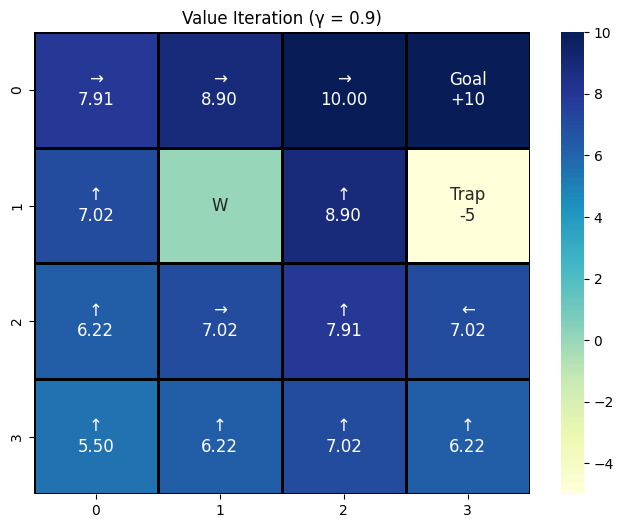


Converged after 7 iterations.
Policy with Gamma = 0.1


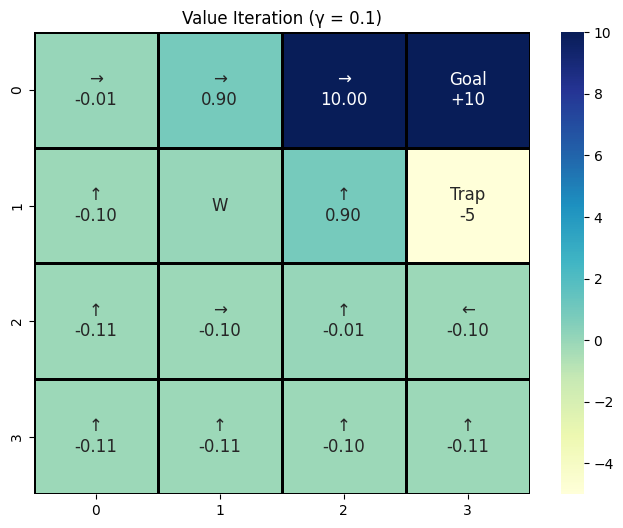

In [34]:
"""
EXPERIMENT
"""
env = GridWorld()

# Run 1: Gamma = 0.9
V_90 = value_iteration(env, gamma=0.9)
policy_90 = get_policy(V_90, env, gamma=0.9)
print("Policy with Gamma = 0.9")
plot_results(V_90, policy_90, env, "Value Iteration (\u03B3 = 0.9)")

print()

# Run 2: Gamma = 0.1
V_10 = value_iteration(env, gamma=0.1)
policy_10 = get_policy(V_10, env, gamma=0.1)
print("Policy with Gamma = 0.1")
plot_results(V_10, policy_10, env, "Value Iteration (\u03B3 = 0.1)")

### **Discussion & Analysis**
#### **Why this setup is a Markov Decision Process (MDP)**
This Grid World setup is a textbook Markov Decision Process (MDP) because it runs on one simple rule: the future only depends on where you are right now, not how you got there. This is known as the Markov Property. The system doesn't have a memory, so the path the agent took to reach a specific square doesn't change what happens next. We define this environment using five main parts:
- **State Space ($S$):** Every valid square on the grid that the agent can actually stand on.
- **Action Space ($A$):** The four possible moves (Up, Down, Left, Right).
- **Transition Function ($P$):** The rules of movement. Since our grid is deterministic, if the agent decides to move "Up", it will successfully move "Up" 100% of the time unless a wall or the edge of the board blocks it.
- **Rewards ($R$):** The point system that gives feedback. We give +10 for the goal, -5 for hitting the trap, and a small -0.1 penalty for every normal step to push the agent to find the shortest path.
- **Discount Factor ($\gamma$):** A tuning knob that tells the agent how much to care about future rewards versus immediate rewards.
#### **What the learned policy is doing:**
The final policy $\pi^*$ is basically a cheat sheet that tells the agent the absolute best move to make from any square on the board to get the highest score. By changing the discount factor ($\gamma$), we can completely change how the agent approaches the problem:
- **With $\gamma = 0.9$ (Thinking ahead):** The agent plays the long game. It cares a lot about that +10 goal, even if it is far away. The policy calculates a safe path around the wall, totally avoids the -5 trap, and willingly eats the tiny -0.1 step penalties because it knows the big payoff is waiting at the end.
- **With $\gamma = 0.1$ (Short-sighted):** The agent basically stops caring about anything more than a step or two away. Because we discount future rewards by 90% each step, the mathematical "pull" of the goal drops off incredibly fast. For squares that aren't right next to the goal, the agent just tries to survive the immediate next move, causing the expected values of those distant squares to instantly drop below zero.

## **Part 2: Mini Research Task on a Novel AI Topic**
### **Task 2**
Complete one scoped mini research task on a recent AI topic. Diffusion models are strongly encouraged, but you may choose another novel topic.

Examples of acceptable topics include diffusion models, consistency modes, flow matching, multimodal foundation models, retrieval-augmented generation, parameter-efficient fine-tuning, graph neural networks, or another recent topic in the field of AI.

**Perform the following:**
- Select one focused topic and identify at least two technical sources. At least one source should be a primary source such as a research paper, official documentation, or a model card.
- Explain the problem the method is trying to solve, the core idea behind the method, and the main architecture or training objective in your own words.
- Include one small hands-on component. For example, you may run a simple demo, inspect a pretrained model or pipeline, reproduce one small figure or result, compare two variants, or analyze how one key design choice affects outputs.
- If you choose diffusion models, possible hands-on directions include comparing different numbers of denoising steps, comparing schedulers, testing prompt sensitivity, or explaining the forward and reverse diffusion process with a compact experiment.
- Include at least one figure, table, or carefully labeled output example that supports your analysis.
- Discuss at least two limitations, risk, or open challenges related to the method.
- Propose one concrete extension, improvement, or follow-up experiment that you would pursue next.

The goal is depth on one focused recent topic, not breadth across many topics.

#### **Diffusion Models**
##### **Sources:**
1. **Primary:** [Jo, J., Jain, A., & Abbeel, P. (2020). *Denoising Diffusion Probabilistic Models. Advances in Neural Information Processing Systems*](https://proceedings.neurips.cc/paper_files/paper/2020/file/4c5bcfec8584af0d967f1ab10179ca4b-Paper.pdf).
2. **Secondary:** The Hugging Face `diffusers` Official Documentation.

##### **The Problem:**
Historically, deep generative models like Generative Adversarial Networks (GANs) have been notoriously unstable to train, often suffering from "mode collapse" (where the model only learns to generate a single type of output). The problem diffusion models solve is how to generate high-fidelity, diverse data through a mathematically stable, non-adversarial training objective.

##### **The Core Idea & Architecture:**
Instead of trying to generate a complex image out of nothing in one shot, diffusion models break the problem down into a slow, iterative process inspired by non-equilibrium thermodynamics.
- **The Forward Process:** The model takes a clean piece of data and gradually adds random Gaussian noise over $T$ steps until the data is completely destroyed, leaving pure static.
- **The Reverse Process (Architecture):** A neural network (typically a U-Net with attention mechanisms) is trained to reverse this exact process. Given a noisy image at step $t$, the network predicts the exact noise that was added. By subtracting this predicted noise step-by-step, the model slowly "denoises" pure static back into a crystal-clear, generated image.

##### **Limitations & Open Challenges:**
1. **High Computational Cost:** Because the generation process requires running the U-Net for every single denoising step (often 50 to 1000 times for a single output) diffusion models are extremely GPU-intensive.
2. **Slow Inference Speed:** The reverse process is inherently sequential. We cannot calculate step 49 until we have completed step 50. This makes real-time generation highly challenging compared to older, single-pass models.

##### **Proposed Extension:**
To address the slow inference speeds, our proposed follow-up experiment would involve researching and implementing **Consistency Models**. These are a recent architectural evolution designed to mathematically "distill" a pre-trained diffusion model, allowing it to generate high-quality data in just 1 to 2 steps instead of 50, drastically reducing latency while maintaining fidelity.

In [1]:
"""
IMPORTS
"""
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
"""
LOAD PRE-TRAINED PIPELINE
"""
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
"""
DEFINING PROMPT AND RUNNING MODEL
"""
prompt = "A highly detailed shiny Bulbasaur from Pokemon"

# Use a manual seed so that the static is identical for both runs
generator = torch.Generator("cuda").manual_seed(1000)

# Run 1: 5 Denoising Steps (Rushed)
print("Running 5-step generation...")
image_5_steps = pipe(prompt, num_inference_steps=5, generator=generator).images[0]

# Run 2: 50 Denoising Steps (Standard)
image_50_steps = pipe(prompt, num_inference_steps=50, generator=generator).images[0]

Running 5-step generation...


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

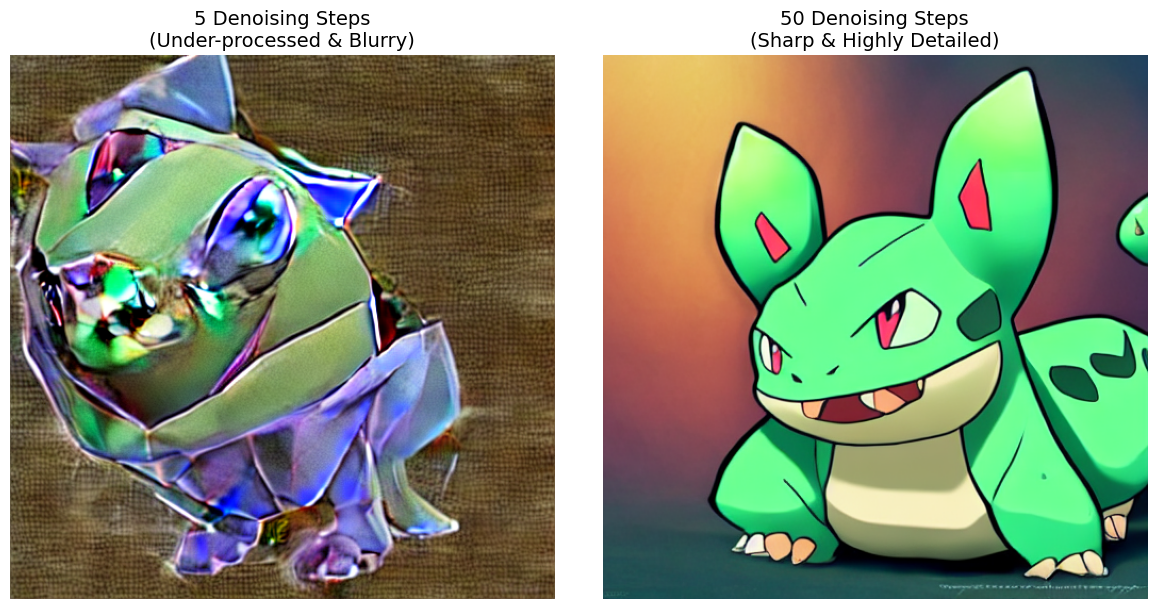

In [12]:
"""
VISUALIZATION
"""
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image_5_steps)
axes[0].set_title("5 Denoising Steps\n(Under-processed & Blurry)", fontsize=14)
axes[0].axis("off")

axes[1].imshow(image_50_steps)
axes[1].set_title("50 Denoising Steps\n(Sharp & Highly Detailed)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()